In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("moonDataset.csv")
print(df)

X = df[["X1"]]
y = df[["X2"]]

           X1        X2        X3  label
0   -0.926767 -0.111073  0.086017      0
1   -0.917583  0.706006  0.058041      0
2    0.437984  0.899093  0.072543      0
3    0.089694  0.291446  0.070444      1
4    0.110672 -0.070806 -0.090376      1
..        ...       ...       ...    ...
195 -0.540630  0.901834 -0.058539      0
196  0.032085  0.411465 -0.064823      1
197  0.691922  0.679103  0.020613      0
198  0.017034  0.930984 -0.034133      0
199  0.212676 -0.026037  0.013321      1

[200 rows x 4 columns]


In [5]:
poly = PolynomialFeatures(degree = 4)
X_poly = poly.fit_transform(X)

In [7]:
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

In [8]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("mse:", mse)
print("r2:", r2)

mse: 0.16486576914824622
r2: 0.35243118621395075


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


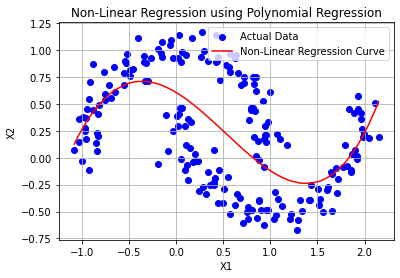

In [11]:
X_sorted = np.sort(X, axis=0)
Y_sorted_pred = model.predict(poly.transform(X_sorted))

plt.scatter(X.values.flatten(), y.values.flatten(), color="b", label="Actual Data")
plt.plot(X_sorted.flatten(), Y_sorted_pred.flatten(), color="r", label="Non-Linear Regression Curve")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Non-Linear Regression using Polynomial Regression")
plt.legend()
plt.grid()

In [12]:
new_X1 = [[0.05]]
new_X1_poly = poly.transform(new_X1)
prediction = model.predict(new_X1_poly)

print("Predicated Disease Progression:", prediction)

Predicated Disease Progression: [[0.57989194]]


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
